In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import Counter

Cellule 2 — Définir les chemins

In [3]:
# Adapter selon ton os.getcwd()
OCT_PATH  = "../data/OCT"
XRAY_PATH = "../data/chest_xray"

Cellule 3 — Nettoyage : Vérifier images corrompues

In [3]:
def verifier_images(base_path):
    corrompues = []
    total      = 0

    for split in ['train', 'test']:
        split_path = os.path.join(base_path, split)
        for classe in os.listdir(split_path):
            classe_path = os.path.join(split_path, classe)
            if not os.path.isdir(classe_path):
                continue
            for img_file in os.listdir(classe_path):
                img_path = os.path.join(classe_path, img_file)
                total += 1
                try:
                    img = Image.open(img_path)
                    img.verify()
                except Exception as e:
                    corrompues.append(img_path)

    print(f"Total images vérifiées : {total}")
    print(f"Images corrompues      : {len(corrompues)}")
    if corrompues:
        for c in corrompues:
            print(f"  ❌ {c}")
    else:
        print("✅ Aucune image corrompue !")

    return corrompues

print("=== OCT ===")
corrompues_oct  = verifier_images(OCT_PATH)

print("\n=== X-RAY ===")
corrompues_xray = verifier_images(XRAY_PATH)

=== OCT ===
Total images vérifiées : 84484
Images corrompues      : 0
✅ Aucune image corrompue !

=== X-RAY ===
Total images vérifiées : 5856
Images corrompues      : 0
✅ Aucune image corrompue !


verification des doublons : Code avec Hash MD5

In [4]:
import hashlib

def verifier_doublons_hash(base_path):
    hash_dict = {}  # hash → liste de chemins
    doublons  = []
    total     = 0

    for split in ['train', 'test']:
        split_path = os.path.join(base_path, split)
        for classe in os.listdir(split_path):
            classe_path = os.path.join(split_path, classe)
            if not os.path.isdir(classe_path):
                continue
            for img_file in os.listdir(classe_path):
                img_path = os.path.join(classe_path, img_file)
                total += 1

                # Calculer le hash MD5 du fichier
                with open(img_path, 'rb') as f:
                    hash_md5 = hashlib.md5(f.read()).hexdigest()

                if hash_md5 in hash_dict:
                    doublons.append({
                        'original'  : hash_dict[hash_md5],
                        'doublon'   : img_path,
                        'hash'      : hash_md5
                    })
                else:
                    hash_dict[hash_md5] = img_path

    print(f"Total images analysées : {total}")
    print(f"Doublons trouvés       : {len(doublons)}")

    if doublons:
        print("\nExemples de doublons :")
        for d in doublons[:3]:
            print(f"  Hash     : {d['hash']}")
            print(f"  Original : {d['original']}")
            print(f"  Doublon  : {d['doublon']}")
            print()
    else:
        print("✅ Aucun doublon détecté !")

    return doublons

print("=== OCT ===")
doublons_oct  = verifier_doublons_hash(OCT_PATH)

print("\n=== X-RAY ===")
doublons_xray = verifier_doublons_hash(XRAY_PATH)

=== OCT ===
Total images analysées : 84484
Doublons trouvés       : 7582

Exemples de doublons :
  Hash     : 8e96347ce7da5ff54075653d5069d04d
  Original : ../data/OCT\train\CNV\CNV-1016042-101.jpeg
  Doublon  : ../data/OCT\train\CNV\CNV-1016042-102.jpeg

  Hash     : 8e96347ce7da5ff54075653d5069d04d
  Original : ../data/OCT\train\CNV\CNV-1016042-101.jpeg
  Doublon  : ../data/OCT\train\CNV\CNV-1016042-103.jpeg

  Hash     : e4a5b7348a21c514a8106d18f6fbd572
  Original : ../data/OCT\train\CNV\CNV-1016042-104.jpeg
  Doublon  : ../data/OCT\train\CNV\CNV-1016042-105.jpeg


=== X-RAY ===
Total images analysées : 5856
Doublons trouvés       : 32

Exemples de doublons :
  Hash     : dcc3ab0eaf19ff80af9d3d254b340da5
  Original : ../data/chest_xray\train\NORMAL\NORMAL2-IM-0587-0001-0001.jpeg
  Doublon  : ../data/chest_xray\train\NORMAL\NORMAL2-IM-0587-0001-0002.jpeg

  Hash     : edbf5c2810fce5b00722716ab730e577
  Original : ../data/chest_xray\train\PNEUMONIA\person1159_virus_1944.jpeg
  Doublon

Si des doublons sont trouvés → les supprimer

In [5]:
def supprimer_doublons(doublons):
    if not doublons:
        print("✅ Rien à supprimer")
        return

    for d in doublons:
        if os.path.exists(d['doublon']):
            os.remove(d['doublon'])
            print(f"🗑️  Supprimé : {d['doublon']}")

    print(f"\n✅ {len(doublons)} doublon(s) supprimé(s)")

supprimer_doublons(doublons_oct)
supprimer_doublons(doublons_xray)

🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-102.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-103.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-105.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-106.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-108.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-109.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-11.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-111.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-112.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-114.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-116.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-117.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-119.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-12.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-120.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-122.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-123.jpeg
🗑️  Supprimé : .

taille des données apres nettoyage 

In [6]:
def compter_classes(base_path):
    resultats = {}
    for split in ['train', 'test']:
        split_path = os.path.join(base_path, split)
        resultats[split] = {}
        for classe in os.listdir(split_path):
            classe_path = os.path.join(split_path, classe)
            if os.path.isdir(classe_path):
                nb = len(os.listdir(classe_path))
                resultats[split][classe] = nb
    return resultats

# Chemins corrigés
oct_stats  = compter_classes("../data/OCT")
xray_stats = compter_classes("../data/chest_xray")

print("=== OCT ===")
for split, classes in oct_stats.items():
    print(f"\n{split.upper()} :")
    for classe, nb in classes.items():
        print(f"  {classe} : {nb} images")

print("\n=== CHEST X-RAY ===")
for split, classes in xray_stats.items():
    print(f"\n{split.upper()} :")
    for classe, nb in classes.items():
        print(f"  {classe} : {nb} images")

=== OCT ===

TRAIN :
  CNV : 31635 images
  DME : 10918 images
  DRUSEN : 7830 images
  NORMAL : 26114 images

TEST :
  CNV : 14 images
  DME : 209 images
  DRUSEN : 9 images
  NORMAL : 173 images

=== CHEST X-RAY ===

TRAIN :
  NORMAL : 1348 images
  PNEUMONIA : 3858 images

TEST :
  NORMAL : 231 images
  PNEUMONIA : 387 images


Nettoyage : Détecter outliers

In [7]:
def detecter_outliers(base_path, seuil_noir=10, seuil_blanc=245):
    outliers = []

    for split in ['train', 'test']:
        split_path = os.path.join(base_path, split)
        for classe in os.listdir(split_path):
            classe_path = os.path.join(split_path, classe)
            if not os.path.isdir(classe_path):
                continue
            for img_file in os.listdir(classe_path):
                img_path = os.path.join(classe_path, img_file)
                try:
                    img      = np.array(Image.open(img_path).convert('L'))
                    moyenne  = img.mean() # moyenne = luminosité globale de l’image
                    if moyenne < seuil_noir or moyenne > seuil_blanc:
                        outliers.append((img_path, round(moyenne, 2)))
                except:
                    pass

    print(f"Outliers détectés : {len(outliers)}")
    for path, moy in outliers[:5]:  # afficher les 5 premiers
        print(f"  ⚠️  moyenne={moy} → {path}")

    if not outliers:
        print("✅ Aucun outlier détecté !")

    return outliers

print("=== OCT ===")
outliers_oct  = detecter_outliers(OCT_PATH)

print("\n=== X-RAY ===")
outliers_xray = detecter_outliers(XRAY_PATH)

=== OCT ===
Outliers détectés : 0
✅ Aucun outlier détecté !

=== X-RAY ===
Outliers détectés : 0
✅ Aucun outlier détecté !


Analyser tailles des images

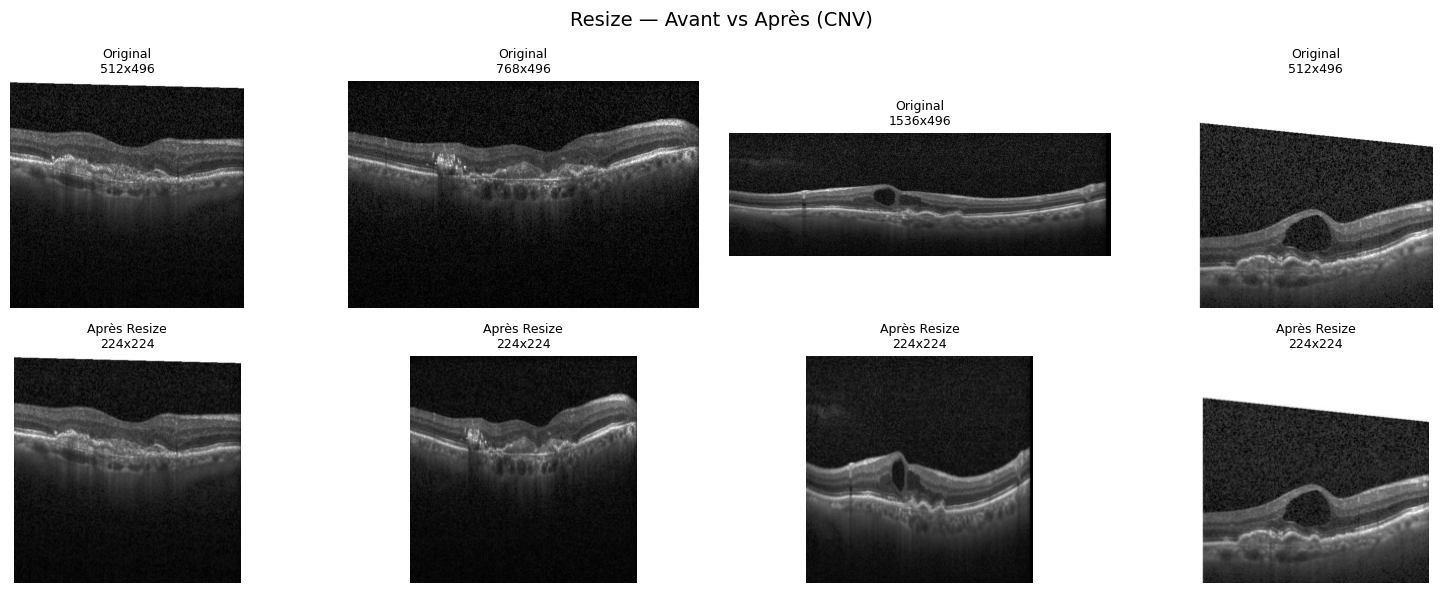

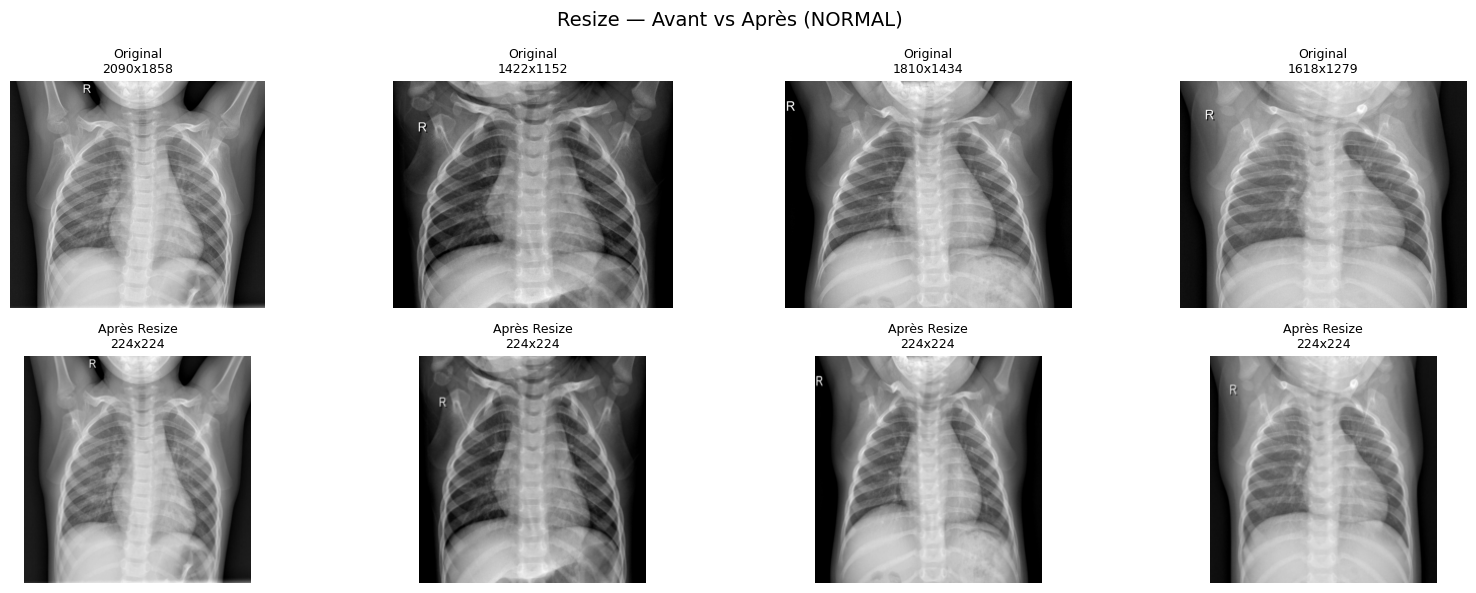

✅ Resize : toutes les images → 224x224 px


In [8]:
IMG_SIZE = 224

# Transform UNIQUEMENT resize — pour vérifier avant/après
resize_only = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),   # juste pour pouvoir afficher
])

# ── Vérification visuelle avant/après resize ──────────────────────────────────
def verifier_resize(base_path, classe, n=4):
    classe_path = os.path.join(base_path, "train", classe)
    images_files = os.listdir(classe_path)[:n]

    fig, axes = plt.subplots(2, n, figsize=(n * 4, 6))
    fig.suptitle(f"Resize — Avant vs Après ({classe})", fontsize=14)

    for j, img_file in enumerate(images_files):
        img_orig = Image.open(os.path.join(classe_path, img_file)).convert('RGB')
        img_resized = resize_only(img_orig)

        # Avant
        axes[0][j].imshow(img_orig, cmap='gray')
        axes[0][j].set_title(f"Original\n{img_orig.size[0]}x{img_orig.size[1]}", fontsize=9)
        axes[0][j].axis('off')

        # Après
        axes[1][j].imshow(img_resized.permute(1, 2, 0).numpy())
        axes[1][j].set_title(f"Après Resize\n{IMG_SIZE}x{IMG_SIZE}", fontsize=9)
        axes[1][j].axis('off')

    plt.tight_layout()
    plt.savefig(f"../results/resize_verification_{classe}.png")
    plt.show()

# Tester sur une classe OCT et une X-Ray
verifier_resize(OCT_PATH,  "CNV")
verifier_resize(XRAY_PATH, "NORMAL")

print(f"✅ Resize : toutes les images → {IMG_SIZE}x{IMG_SIZE} px")